In [1]:
#%% GENERAL LIBRARIES

# General
import sys
import os
from os.path import dirname, abspath
from glob import glob
import numpy as np
import pandas as pd
from osgeo import gdal, osr

# Plot
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import matplotlib as mpl
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LightSource
from matplotlib.pyplot import cm
from matplotlib.ticker import MaxNLocator

# Gis
from osgeo import gdal
import imageio
import rasterio
import geopandas as gpd
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = True

# Warnings
import logging
import warnings
logging.captureWarnings(True)


In [2]:
#%% HYDROMODPY MODULES

# Path
DIR = "C:/Users/alexa/Documents/GitHub/HydroModPy/CORE_COMM/"
sys.path.append(DIR)

# Class
from watershed import watershed_root, forcing, watershed_display
from tools import tif_adds, serie_transf, tif_features, file_adds, to_plot, vtk
from watershed.data import hydrology, climatic, oceanic, piezometry
from groundwater_flow import plots

# Plot
fontprop = to_plot.plot_params(8,15,18,20) # small, medium, interm, large


In [3]:
#%% NECESSARY INPUT PATHS

# Path to the git repositoty home page
git_path = DIR
# Path to the test folder
test_path = git_path + "examples/_example/"
# Path where the results will be stored
out_path = "C:/Users/alexa/Dropbox/HydroModPy/"

# We suggest to store the data in specific folder
dems_path = test_path + 'dem/'
hydrology_path = test_path + 'hydrology/' # add hydrographic shapefiles
modflow_path = test_path + 'modflow/' # add bin/ folder with necessary .exe
climate_path =test_path + 'climate/'

piezometry_path = None # add piezometry data or nothing for automatic download
geology_path = None # add geologic layers
oceanic_path = None # add specific sea level files

# Specifically designed to process SURFEX data (France scale)
surfex_path =  None # add surfex models in .h5 format

# Indicate the name of the regional DEM
dem_name = "DEM_test_75m_LAMB93.tif"
# dem_name = "DEM_bzh_75m_LAMB93.tif"
dem_path = dems_path + dem_name

dem = gdal.Open(dem_path)
proj = osr.SpatialReference(wkt=dem.GetProjection())
crs = int(proj.GetAttrValue('AUTHORITY',1))

# Import the library of watersheds to generate
library_path = test_path + 'watershed_library.csv' # each row is a study site
library = pd.read_csv(library_path, sep=';', header=0, engine='python') # explore catchment studied

# Select from the library the interest catchment
watershed_name = 'Example' # add manually study site information in map units
mysite = library[library['watershed_name'] == watershed_name] # specific row

# Paths generated automatically but necessary for plots
stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/'
simulations_folder = out_path+'/'+watershed_name+'/'+'results_simulations/'

# Specify the hydrologic layers to clip
types_obs = ['streams','sections'] # list of shapefile name layers
fields_obs = ['FID','Persistanc'] # list of shapefile name columns to translate in a tif


##### EXAMPLE #####
Object was loaded successfully


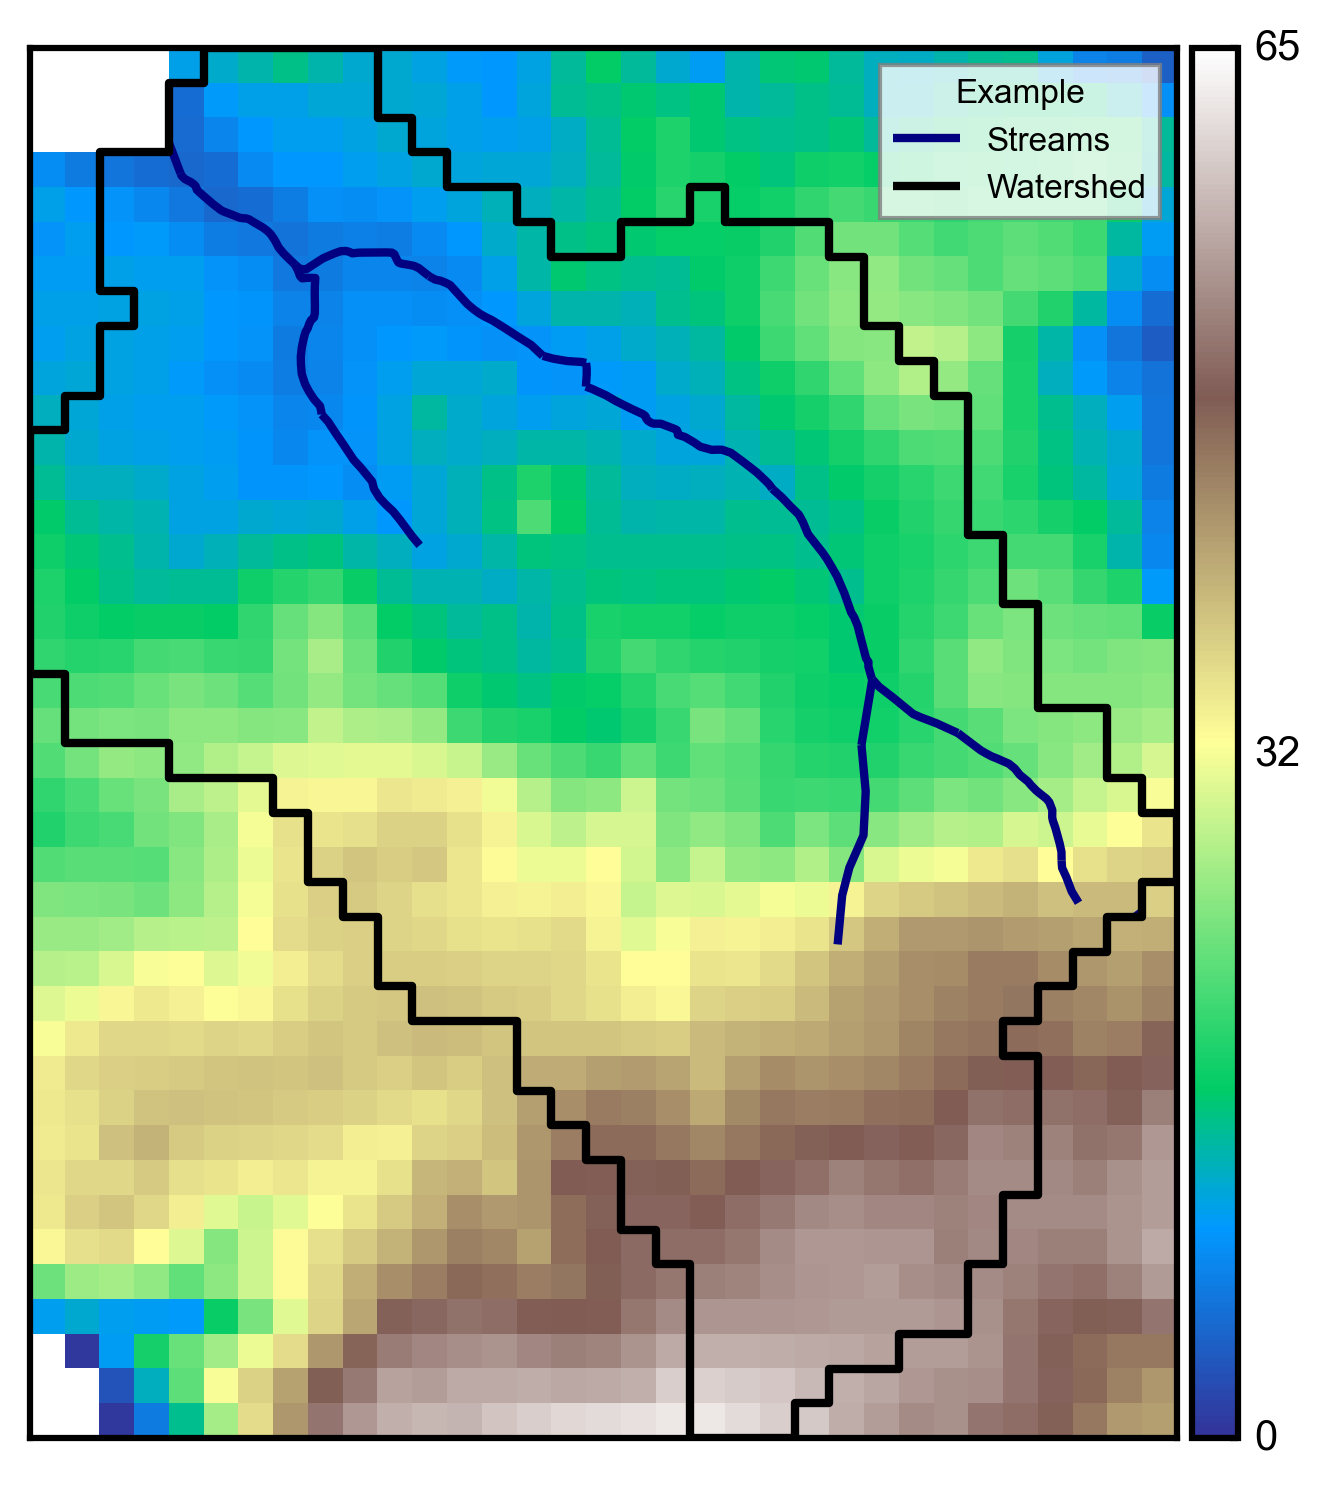

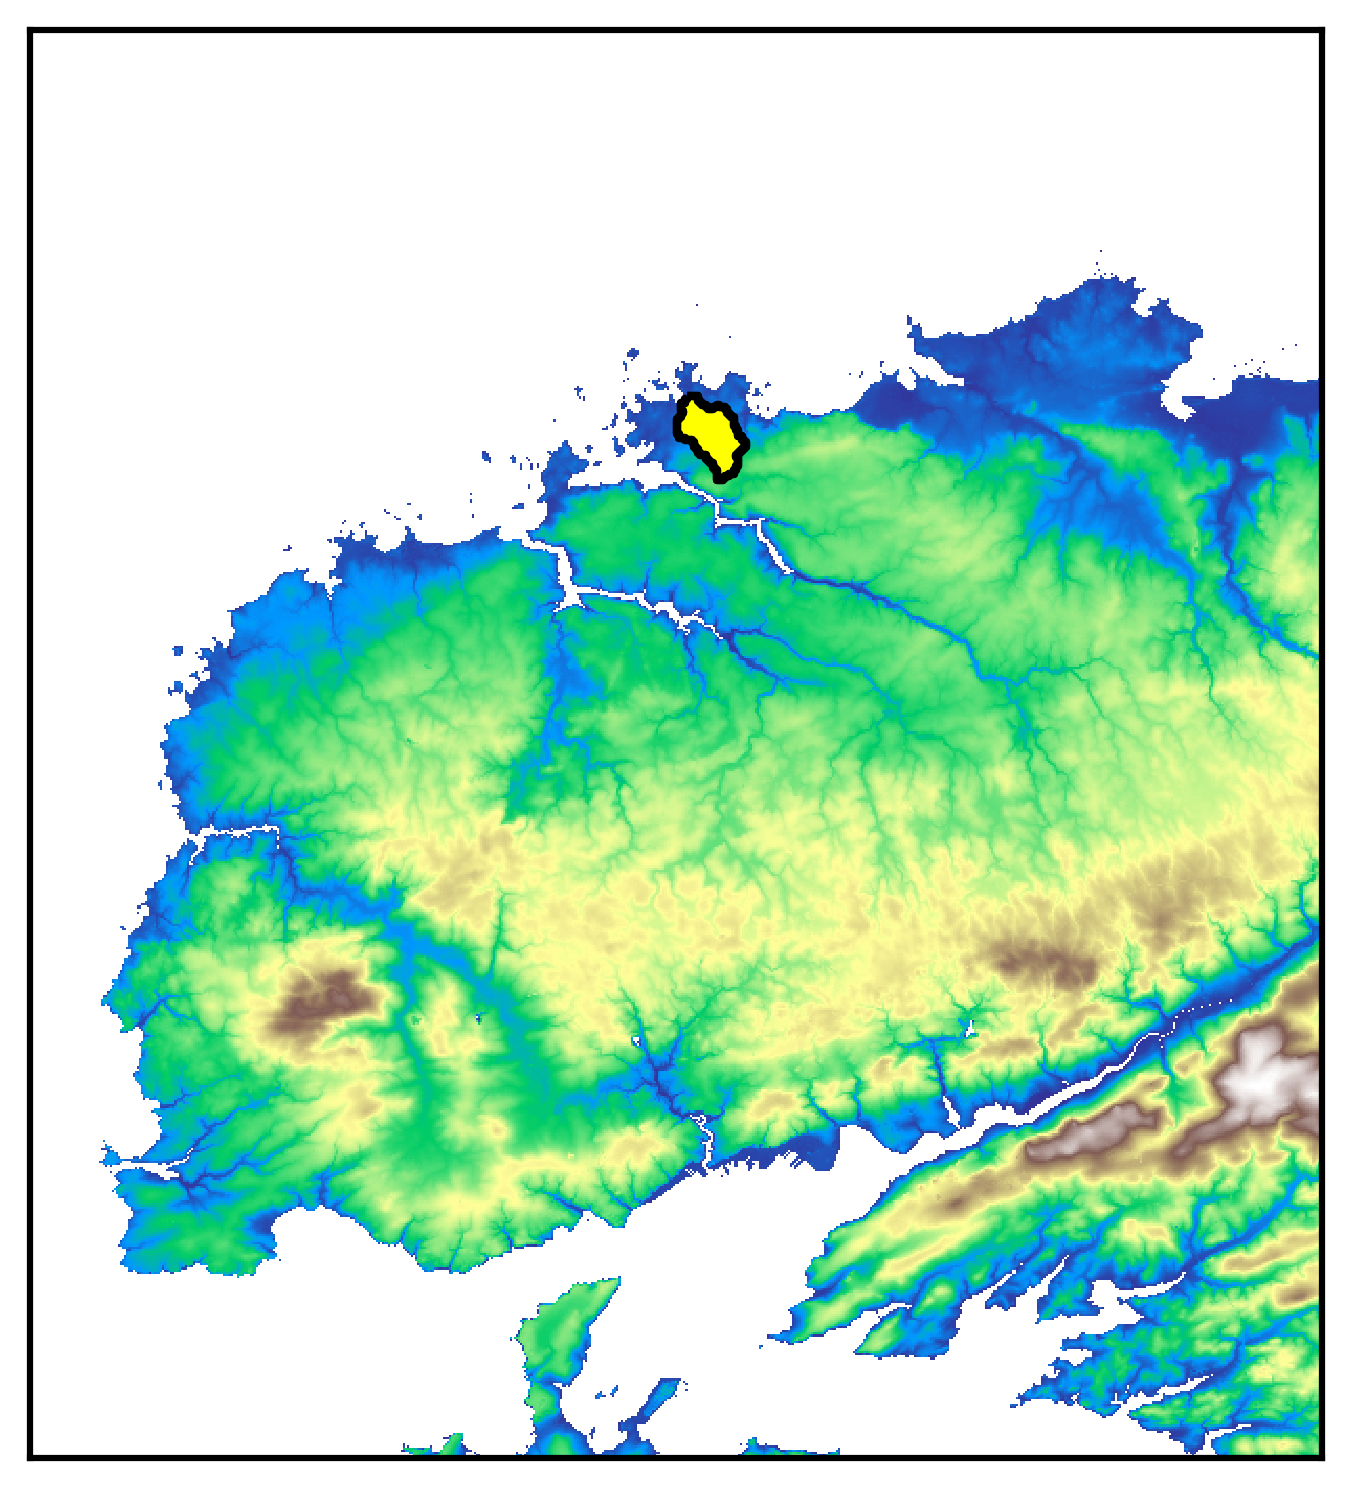

In [4]:
#%% GENERATING WATERSHED

load = True
print('##### '+watershed_name.upper()+' #####')

try:
    BV = watershed_root.Watershed(watershed_name=watershed_name,
                                  dem_path=dem_path, 
                                  out_path=out_path,
                                  surfex_path=surfex_path, 
                                  geology_path = geology_path, 
                                  hydrology_path=hydrology_path,
                                  oceanic_path=oceanic_path, 
                                  piezometry_path=piezometry_path,
                                  modflow_path=modflow_path,
                                  library_path=library_path,
                                  load=load,
                                  types_obs=types_obs,
                                  fields_obs=fields_obs)
except:
    print('There is a problem to generate the watershed object')

watershed_display.watershed_dem(BV)
watershed_display.watershed_local(dem_path, BV)


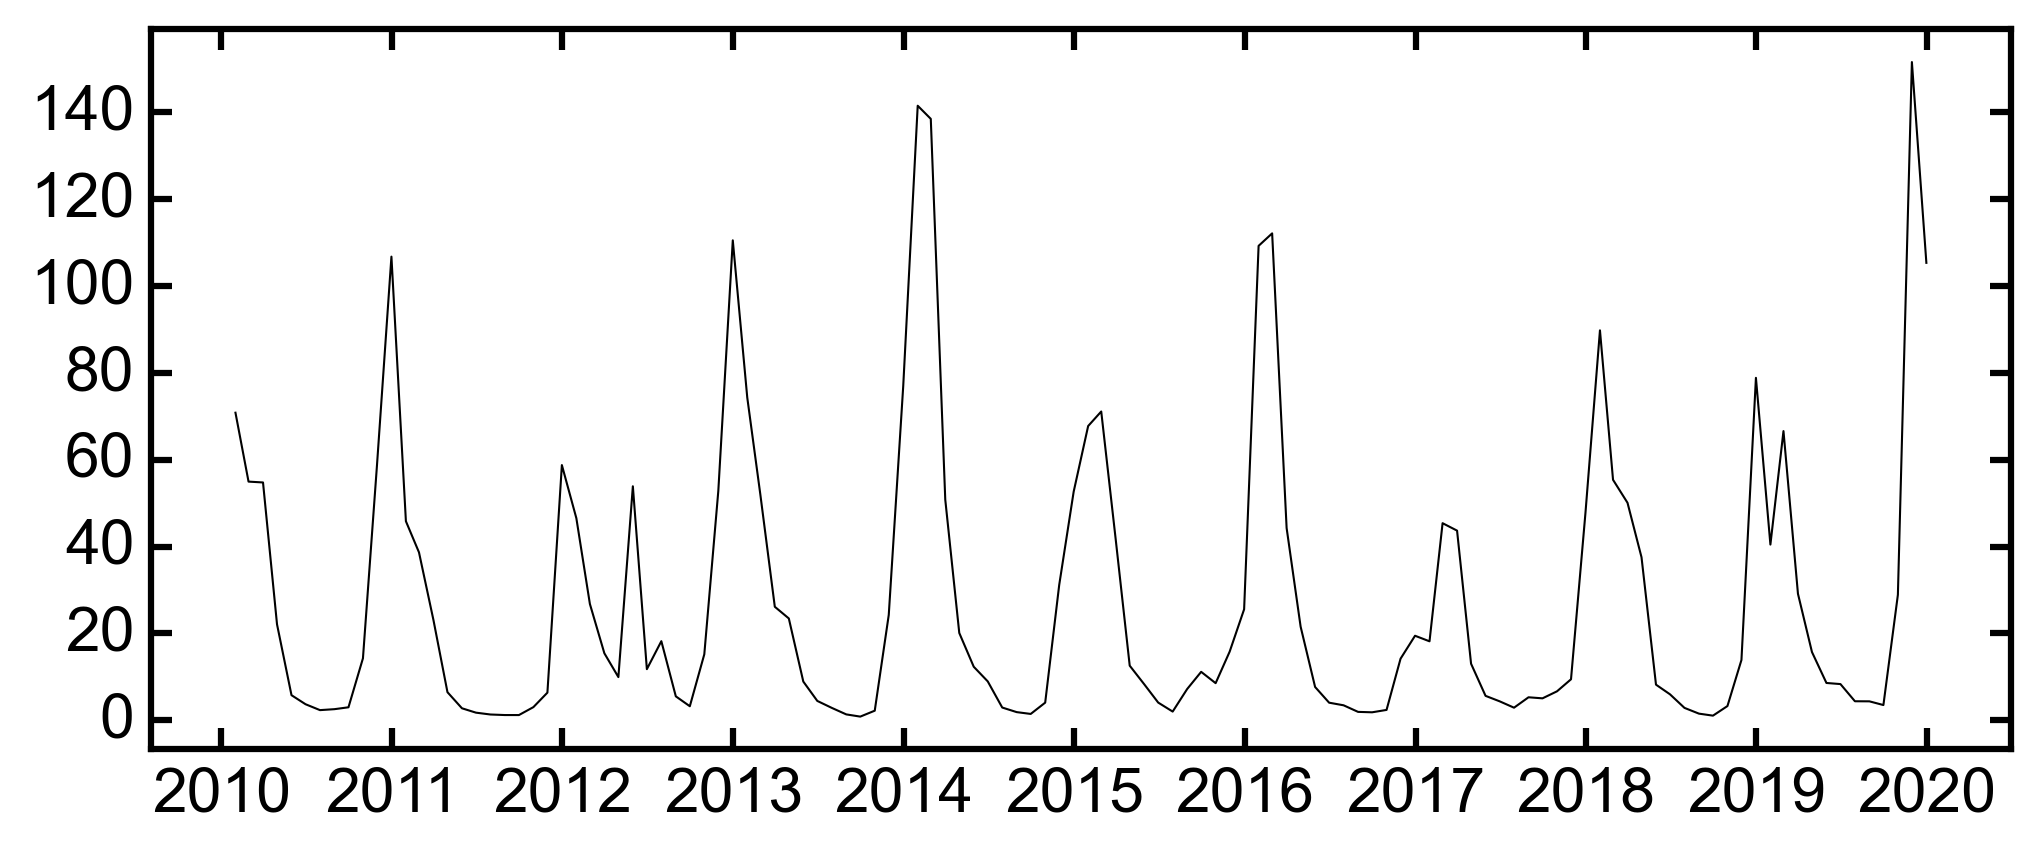

In [5]:
#%% SET PARAMETERS

# Choice the state of the simulation
sim_state = 'transient' # steady
first = 2010
last = 2019
time_step = 'M'

# Recharge from a csv
rec = pd.read_csv(climate_path+'_REC_'+time_step+'.csv', sep=';', index_col=[0], parse_dates=True)
rec = rec[(rec.index.year>=first) & (rec.index.year<=last)]
rec = rec.squeeze()
BV.forcing.update_recharge(values = rec / 1000, sim_state=sim_state)

# Finally the rehcarge is set as a value or a serie
R = BV.forcing.recharge # mm/month to m/month

# Plot to control recharge
if sim_state == 'transient':
    fig, ax = plt.subplots(1,1, figsize=(8,3))
    ax.plot(R*1000, c='k', lw=0.5)

# Update hydrualic conductivity
K = 1e-5 * 3600 * 24 * 30 # m/second to m/month
BV.hydrodynamic.update_hyd_cond(K)

# Update aquifer thickness
E = 30 # m
BV.hydrodynamic.update_thickness(E)

# Update effective porosity
P = 0.01 # -
BV.hydrodynamic.update_porosity(P)

# Set name of the model
model_name = sim_state

In [6]:
#%% RUN MODEL

# Launch a model
BV.run_modflow(ident=model_name, modpath_sim=False, calib=False, sink_fill=False, 
                lay_number=1, bottom=None, thick_exp=1., sea_level=None, cond_decay=0., 
                verbose=True)
print('Modeling process completed')

# Extract result chronics
BV.chronics_modflow(ident=model_name, mask=False, outlet_type=True, calib_only=False, 
                    first=first, last=last, time_step='monthly')
print('Result chronics extraction completed')


Simulation d'un modèle
FloPy is using the following  executable to run the model: C:/Users/alexa/Documents/GitHub/HydroModPy/CORE_COMM/examples/_example/modflow//bin/mfnwt.exe

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.1.4 4/01/2018                         
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.04.0 09/15/2016                       

 Using NAME file: transient.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2021/12/23 22:56:24

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     2    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     3    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     4    Time step:     1    Groundwat

CPLE_AppDefinedError: Deleting C:/Users/alexa/Dropbox/HydroModPy/Example/results_simulations/transient/_extraction/_surfaceflow/_eff_outflow_drain_t(xxx).tif failed: Permission denied

In [7]:
#%% PLOT SURFACE OUTPUTS

if sim_state=='transient':
    plots.SurfaceOutputs(R, simulations_folder, stable_folder, model_name, types_obs, freq_interv=12, save_gif=True)

Plot step : 0 / 120
Plot step : 1 / 120
Plot step : 2 / 120
Plot step : 3 / 120
Plot step : 4 / 120
Plot step : 5 / 120
Plot step : 6 / 120
Plot step : 7 / 120
Plot step : 8 / 120
Plot step : 9 / 120
Plot step : 10 / 120
Plot step : 11 / 120
Plot step : 12 / 120
Plot step : 13 / 120
Plot step : 14 / 120
Plot step : 15 / 120
Plot step : 16 / 120
Plot step : 17 / 120
Plot step : 18 / 120
Plot step : 19 / 120
Plot step : 20 / 120
Plot step : 21 / 120
Plot step : 22 / 120
Plot step : 23 / 120
Plot step : 24 / 120
Plot step : 25 / 120
Plot step : 26 / 120
Plot step : 27 / 120
Plot step : 28 / 120
Plot step : 29 / 120
Plot step : 30 / 120
Plot step : 31 / 120
Plot step : 32 / 120
Plot step : 33 / 120
Plot step : 34 / 120
Plot step : 35 / 120
Plot step : 36 / 120
Plot step : 37 / 120
Plot step : 38 / 120
Plot step : 39 / 120
Plot step : 40 / 120
Plot step : 41 / 120
Plot step : 42 / 120
Plot step : 43 / 120
Plot step : 44 / 120
Plot step : 45 / 120
Plot step : 46 / 120
Plot step : 47 / 120
Pl

In [12]:
#%% INTERACTIVE CROSS-SECTION

# Dem data
dem_data = BV.geographic.dem_data
# dem_data = imageio.imread(stable_folder+'/geographic/'+'watershed_box_buff_dem.tif')
# dem_data = imageio.imread(stable_folder+'/geographic/'+'watershed_dem.tif')

# Wt data
wt_data = imageio.imread(simulations_folder+model_name+'/_extraction/'+'watertable_elevation_(000).tif') # buffer size no masked

# River data
river_data = imageio.imread(stable_folder+'/hydrology/'+'sections.tif')

# Function
plots.interactive_cross_section(dem_data, wt_data, river_data, interactive=False)


In [ ]:
from groundwater_flow import vizualisation
vtk.VTK(BV, model_name)
visu = vizualisation.Vizualisation(BV, model_name)
visu.visual3D(interactive=True, object_list=['grid','watertable','watertable_depth'], view='south-west')

grid
watertable
watershed_boundary
streams
Error in load(): cannot load C:/Users/alexa/Dropbox/HydroModPy/Example\results_simulations\transient\_extraction\VTK\VTU_Pathlines.vtk
VTK pathlines doesn't exist
(141187.5, 6855562.5, 10914.000244140625)
grid 0
Multirendering is not supported in jupyter.
watertable 1
Multirendering is not supported in jupyter.
